# 📓 Week 13 — DRL + SecurityBERT Integration

## Where we are
```
Part 1 (NB01–NB08): SecurityBERT trained → final_model.pt (98.2% accuracy)
Part 2 (NB11–NB12): PPO agent trained   → ppo_agent_trained.pt (83.8% accuracy)

This notebook connects them into ONE pipeline:

Raw tokenized input
    ↓
SecurityBERT (final_model.pt)
    → attack_probs: shape (15,)  ← real model output
    ↓
state = [attack_probs(15) + net_stats(10) + history(5)]  shape (30,)
    ↓
PPO Agent (ppo_agent_trained.pt)
    → action: int  ← healing decision
    ↓
Week 14: SelfHealingManager.execute(action)
```

## 📋 Roadmap
| Step | Task |
|------|------|
| 1 | Imports & Setup |
| 2 | Load SecurityBERT |
| 3 | Load PPO Agent |
| 4 | IntegratedSecuritySystem class |
| 5 | Network stats extractor |
| 6 | End-to-end pipeline test |
| 7 | Batch evaluation on tokenized_sequences.pt |
| 8 | Per-class action distribution analysis |
| 9 | Latency profiling |
| 10 | Save integration report |

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import warnings
import json
import time
import math
import random
from pathlib     import Path
from typing      import List, Tuple, Dict, Optional
from collections import deque, defaultdict

# ── Data ──────────────────────────────────────────────────────────────────────
import numpy  as np
import pandas as pd

# ── Deep Learning ─────────────────────────────────────────────────────────────
import torch
import torch.nn            as nn
import torch.nn.functional as F
from torch.distributions   import Categorical
from transformers          import BertConfig, BertModel

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn           as sns

warnings.filterwarnings('ignore')

# ── Plot theme ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a', 'axes.facecolor': '#16162a',
    'axes.edgecolor' : '#444477', 'axes.labelcolor': '#ccccff',
    'xtick.color'    : '#aaaacc', 'ytick.color'    : '#aaaacc',
    'text.color'     : '#e0e0ff', 'grid.color'     : '#2a2a4a',
    'grid.linestyle' : '--',      'grid.alpha'     : 0.4,
    'font.family'    : 'DejaVu Sans',
    'legend.facecolor': '#1a1a2e','legend.edgecolor': '#444477',
})
ACCENT='#7c6cfa'; GREEN='#4ecca3'; RED='#fc5c65'
YELLOW='#f7b731'; ORANGE='#fd9644'
PALETTE=['#7c6cfa','#4ecca3','#f7b731','#fc5c65','#45aaf2',
         '#fd9644','#26de81','#a55eea','#2bcbba','#eb3b5a',
         '#20bf6b','#0fb9b1','#8854d0','#4b6584','#778ca3']

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR = Path('..')
CKPT_DIR = BASE_DIR / 'checkpoints'
PROC_DIR = BASE_DIR / 'data' / 'processed'
OUT_DIR  = BASE_DIR / 'outputs' / 'figures' / 'N13'
REP_DIR  = BASE_DIR / 'outputs' / 'reports'

# Inputs from previous notebooks
BERT_CKPT  = CKPT_DIR / 'final_model.pt'        # NB08
PPO_CKPT   = CKPT_DIR / 'ppo_agent_trained.pt'  # NB12
TOKEN_DATA = PROC_DIR / 'tokenized_sequences.pt' # NB04

# Output of this notebook
INTEG_CKPT = CKPT_DIR / 'integrated_system.pt'
INTEG_REP  = REP_DIR  / 'week13_integration_report.json'

for d in [OUT_DIR, REP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ─────────────────────────────────────────────────────────────────────────────
# SHARED CONSTANTS — identical to NB11/NB12
# ─────────────────────────────────────────────────────────────────────────────
CLASS_NAMES = [
    'Backdoor','DDoS_HTTP','DDoS_ICMP','DDoS_TCP','DDoS_UDP',
    'Fingerprinting','MITM','Normal','Password','Port_Scanning',
    'Ransomware','SQL_injection','Uploading','Vulnerability_scanner','XSS',
]
ACTION_NAMES = [
    'BLOCK_IP','RESET_CONNECTION','RESTART_SERVICE',
    'ISOLATE_DEVICE','LOG_AND_ALERT',
]
OPTIMAL_ACTION = {
    'Normal':4,'Fingerprinting':4,
    'Port_Scanning':0,'DDoS_TCP':0,'DDoS_UDP':0,'DDoS_ICMP':0,'DDoS_HTTP':0,
    'SQL_injection':1,'XSS':1,'MITM':1,
    'Uploading':2,'Backdoor':2,'Password':2,'Vulnerability_scanner':2,
    'Ransomware':3,
}
CLASS_SEVERITY = {
    'Normal':0,'Fingerprinting':1,'Port_Scanning':2,'Vulnerability_scanner':3,
    'DDoS_ICMP':4,'DDoS_HTTP':4,'DDoS_UDP':4,'DDoS_TCP':5,'XSS':5,
    'SQL_injection':6,'MITM':7,'Password':7,'Uploading':7,
    'Backdoor':8,'Ransomware':10,
}
CLS_TO_IDX  = {c: i for i, c in enumerate(CLASS_NAMES)}
N_CLASSES   = 15;  N_ACTIONS = 5
N_NET_STATS = 10;  N_HISTORY = 5
STATE_DIM   = N_CLASSES + N_NET_STATS + N_HISTORY   # 30
HIDDEN_DIM  = 128
CONF_THRESH = 0.60    # minimum confidence to trigger healing action

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

assert BERT_CKPT.exists(), f'❌ {BERT_CKPT} — run NB08 first'
assert PPO_CKPT.exists(),  f'❌ {PPO_CKPT}  — run NB12 first'
assert TOKEN_DATA.exists(),f'❌ {TOKEN_DATA} — run NB04 first'

print('✅ Setup complete.')
print(f'   Device : {DEVICE}')
print(f'   BERT   : {BERT_CKPT}')
print(f'   PPO    : {PPO_CKPT}')

c:\Users\kaush\Desktop\LLM Threat Detection on IIOT\SecurityBERT CLAUDE\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Setup complete.
   Device : cuda
   BERT   : ..\checkpoints\final_model.pt
   PPO    : ..\checkpoints\ppo_agent_trained.pt


## 🧠 Step 2 — Load SecurityBERT

In [2]:
class SecurityBERTWithSoftmax(nn.Module):
    """SecurityBERT inference model — identical to NB08."""
    def __init__(self, config: BertConfig):
        super().__init__()
        self.bert       = BertModel(config, add_pooling_layer=True)
        self.dropout    = nn.Dropout(config.hidden_dropout_prob)
        self.classifier = nn.Linear(config.hidden_size, config.num_labels)
        self.softmax    = nn.Softmax(dim=-1)

    def forward(self, input_ids, attention_mask):
        out    = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = self.dropout(out.pooler_output)
        logits = self.classifier(pooled)
        probs  = self.softmax(logits)
        return logits, probs


# Load checkpoint
bert_ckpt = torch.load(BERT_CKPT, map_location=DEVICE, weights_only=False)
bert_cfg  = BertConfig(**bert_ckpt['config'])
bert_model= SecurityBERTWithSoftmax(bert_cfg).to(DEVICE)
bert_model.load_state_dict(bert_ckpt['model_state_dict'])
bert_model.eval()

label_map   = bert_ckpt['label_map']           # {str(idx): class_name}
# Verify label map matches our CLASS_NAMES order
for idx, cls in label_map.items():
    assert CLASS_NAMES[int(idx)] == cls, (
        f'Label map mismatch at {idx}: {cls} != {CLASS_NAMES[int(idx)]}'
    )

bert_params = sum(p.numel() for p in bert_model.parameters())
print('✅ SecurityBERT loaded.')
print(f'   Parameters   : {bert_params:,}')
print(f'   Val Accuracy : {bert_ckpt.get("val_accuracy", 0)*100:.2f}%')
print(f'   Val WF1      : {bert_ckpt.get("val_weighted_f1", 0):.4f}')
print(f'   Classes      : {bert_cfg.num_labels}')
print(f'   Label map    : ✅ matches CLASS_NAMES')

✅ SecurityBERT loaded.
   Parameters   : 1,121,039
   Val Accuracy : 97.27%
   Val WF1      : 0.9742
   Classes      : 15
   Label map    : ✅ matches CLASS_NAMES


## 🤖 Step 3 — Load PPO Agent

In [3]:
class PPOActorCritic(nn.Module):
    """Identical to NB11/NB12 — canonical attribute names."""
    def __init__(self, state_dim=STATE_DIM, action_dim=N_ACTIONS,
                 hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(state_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU(),
        )
        self.actor_head  = nn.Sequential(
            nn.Linear(hidden_dim, 64), nn.ReLU(), nn.Linear(64, action_dim)
        )
        self.critic_head = nn.Sequential(
            nn.Linear(hidden_dim, 64), nn.ReLU(), nn.Linear(64, 1)
        )

    def get_action_and_value(self, state, action=None):
        f    = self.backbone(state)
        dist = Categorical(logits=self.actor_head(f))
        if action is None: action = dist.sample()
        return action, dist.log_prob(action), dist.entropy(), \
               self.critic_head(f).squeeze(-1)

    def get_action(self, state: torch.Tensor) -> Tuple[int, float]:
        """Greedy inference — returns (action_id, confidence)."""
        with torch.no_grad():
            logits = self.actor_head(self.backbone(state))
            probs  = torch.softmax(logits, dim=-1)
            action = probs.argmax(dim=-1)
        return action.item(), probs.max(dim=-1).values.item()


# Load PPO checkpoint
ppo_ckpt   = torch.load(PPO_CKPT, map_location=DEVICE, weights_only=False)
ppo_network= PPOActorCritic(
    state_dim  = ppo_ckpt['state_dim'],
    action_dim = ppo_ckpt['action_dim'],
    hidden_dim = ppo_ckpt.get('hidden_dim', HIDDEN_DIM),
).to(DEVICE)
ppo_network.load_state_dict(ppo_ckpt['model_state_dict'])
ppo_network.eval()

ppo_params = sum(p.numel() for p in ppo_network.parameters())
print('✅ PPO Agent loaded.')
print(f'   Parameters   : {ppo_params:,}')
print(f'   Best reward  : {ppo_ckpt.get("best_reward", 0):.4f}')
print(f'   State dim    : {ppo_ckpt["state_dim"]}  ✅ matches STATE_DIM={STATE_DIM}')
print(f'   Action dim   : {ppo_ckpt["action_dim"]}  ✅ matches N_ACTIONS={N_ACTIONS}')

✅ PPO Agent loaded.
   Parameters   : 37,894
   Best reward  : 199.0187
   State dim    : 30  ✅ matches STATE_DIM=30
   Action dim   : 5  ✅ matches N_ACTIONS=5


## 🔧 Step 5 — Network Stats Extractor

In deployment (Pi), these come from live packet captures.
In this notebook, we derive them from SecurityBERT's
prediction to make the simulation realistic.

In [4]:
class NetworkStatsExtractor:
    """
    Derives 10 network statistics from SecurityBERT's prediction.
    
    In Pi deployment (Week 16) these come from Scapy packet features.
    Here we simulate realistic values per attack class.

    Features (normalised 0-1):
        [0] connection_rate  [1] packet_loss   [2] cpu_load
        [3] memory_usage     [4] active_conns  [5] error_rate
        [6] bandwidth_util   [7] latency_ms    [8] retry_count
        [9] alert_count
    """
    _SIGNATURES = {
        'DDoS_TCP':    [0.9,0.6,0.9,0.7,0.9,0.7,0.9,0.8,0.8,0.8],
        'DDoS_UDP':    [0.9,0.7,0.8,0.6,0.9,0.8,0.9,0.9,0.7,0.8],
        'DDoS_ICMP':   [0.8,0.5,0.7,0.5,0.8,0.6,0.8,0.8,0.6,0.7],
        'DDoS_HTTP':   [0.7,0.4,0.8,0.8,0.7,0.5,0.8,0.7,0.5,0.7],
        'Ransomware':  [0.3,0.2,0.9,0.9,0.3,0.4,0.6,0.3,0.4,0.9],
        'SQL_injection':[0.4,0.1,0.5,0.4,0.4,0.3,0.3,0.3,0.2,0.6],
        'MITM':        [0.3,0.3,0.4,0.4,0.3,0.4,0.4,0.5,0.3,0.7],
        'Backdoor':    [0.2,0.1,0.6,0.7,0.2,0.3,0.4,0.2,0.2,0.8],
        'Port_Scanning':[0.6,0.1,0.3,0.2,0.6,0.2,0.4,0.3,0.3,0.4],
        'Normal':      [0.3,0.1,0.4,0.5,0.3,0.1,0.4,0.2,0.1,0.1],
    }
    _DEFAULT = [0.3,0.1,0.4,0.5,0.3,0.1,0.4,0.2,0.1,0.1]
    _RNG     = np.random.RandomState(SEED)

    @classmethod
    def extract(cls, predicted_class: str, noise: float = 0.03) -> np.ndarray:
        """Return simulated network stats for predicted class."""
        sig   = np.array(cls._SIGNATURES.get(predicted_class, cls._DEFAULT),
                         dtype=np.float32)
        noise = cls._RNG.normal(0, noise, N_NET_STATS).astype(np.float32)
        return np.clip(sig + noise, 0.0, 1.0)

    @classmethod
    def from_packet_features(cls, features: Dict) -> np.ndarray:
        """
        Week 16 integration point — extract from Scapy features.
        Called by detector.py on Raspberry Pi.
        """
        stats = np.array([
            min(features.get('tcp.connection.syn', 0) / 100.0, 1.0),
            min(features.get('tcp.connection.rst', 0) / 10.0,  1.0),
            min(features.get('tcp.len', 0) / 65535.0,          1.0),
            min(features.get('icmp.checksum', 0) / 65535.0,    1.0),
            min(features.get('tcp.ack', 0) / 1e9,              1.0),
            min(features.get('tcp.flags', 0) / 255.0,          1.0),
            min(features.get('udp.stream', 0) / 100.0,         1.0),
            min(features.get('dns.qry.name.len', 0) / 200.0,   1.0),
            min(features.get('mqtt.len', 0) / 1000.0,          1.0),
            min(features.get('mbtcp.len', 0) / 100.0,          1.0),
        ], dtype=np.float32)
        return np.clip(stats, 0.0, 1.0)


print('✅ NetworkStatsExtractor ready.')
# Quick test
for cls in ['Normal', 'DDoS_TCP', 'Ransomware']:
    stats = NetworkStatsExtractor.extract(cls)
    print(f'   {cls:<25}: cpu={stats[2]:.2f}  '
          f'conns={stats[4]:.2f}  '
          f'alerts={stats[9]:.2f}')

✅ NetworkStatsExtractor ready.
   Normal                   : cpu=0.42  conns=0.29  alerts=0.12
   DDoS_TCP                 : cpu=0.91  conns=0.85  alerts=0.76
   Ransomware               : cpu=0.90  conns=0.28  alerts=0.89


## 🔗 Step 4 — IntegratedSecuritySystem

The complete end-to-end pipeline:

```
input_ids (512,) + attention_mask (512,)
         ↓
    SecurityBERT
         ↓
  attack_probs (15,) + predicted_class + confidence
         ↓
  state = [attack_probs(15) | net_stats(10) | history(5)]
         ↓
      PPO Agent
         ↓
  action (0-4) + action_name + action_confidence
         ↓
  IntegrationResult (full record of decision)
```

In [5]:
from dataclasses import dataclass, field

@dataclass
class IntegrationResult:
    """Complete output of one integrated detection+decision cycle."""
    # SecurityBERT output
    predicted_class  : str
    true_class       : str
    confidence       : float
    all_probs        : np.ndarray     # shape (15,)
    bert_correct     : bool
    # PPO output
    action_id        : int
    action_name      : str
    action_confidence: float
    optimal_action   : str
    ppo_correct      : bool
    # Timing
    bert_time_ms     : float
    ppo_time_ms      : float
    total_time_ms    : float
    # State
    net_stats        : np.ndarray


class IntegratedSecuritySystem:
    """
    Full SecurityBERT + PPO DRL Self-Healing pipeline.

    Attributes
    ----------
    bert_model  : SecurityBERTWithSoftmax  (from NB08)
    ppo_network : PPOActorCritic           (from NB12)
    action_history : deque of last N_HISTORY actions
    conf_threshold : minimum BERT confidence to trigger healing
    """

    def __init__(
        self,
        bert_model     : SecurityBERTWithSoftmax,
        ppo_network    : PPOActorCritic,
        conf_threshold : float = CONF_THRESH,
        device         : torch.device = DEVICE,
    ):
        self.bert_model      = bert_model
        self.ppo_network     = ppo_network
        self.conf_threshold  = conf_threshold
        self.device          = device
        self.action_history  = deque([0] * N_HISTORY, maxlen=N_HISTORY)
        self.stats_extractor = NetworkStatsExtractor()

        self.bert_model.eval()
        self.ppo_network.eval()

    def reset_history(self) -> None:
        """Reset action history (call between independent sessions)."""
        self.action_history = deque([0] * N_HISTORY, maxlen=N_HISTORY)

    def run(
        self,
        input_ids     : torch.Tensor,   # (seq_len,) or (1, seq_len)
        attention_mask: torch.Tensor,   # (seq_len,) or (1, seq_len)
        true_class    : str = 'Unknown',
        packet_features: Optional[Dict] = None,
    ) -> IntegrationResult:
        """
        Run full pipeline on one sample.

        Parameters
        ----------
        input_ids      : BBPE token IDs from NB04
        attention_mask : padding mask from NB04
        true_class     : ground truth (for evaluation)
        packet_features: live Scapy features (Pi deployment)
        """
        # ── Ensure batch dimension ────────────────────────────────────────────
        if input_ids.dim() == 1:
            input_ids      = input_ids.unsqueeze(0)
            attention_mask = attention_mask.unsqueeze(0)
        input_ids      = input_ids.to(self.device)
        attention_mask = attention_mask.to(self.device)

        # ── Step 1: SecurityBERT inference ───────────────────────────────────
        t0 = time.perf_counter()
        with torch.no_grad():
            _, probs = self.bert_model(input_ids, attention_mask)
        probs_np     = probs[0].cpu().numpy()
        pred_idx     = int(probs_np.argmax())
        pred_class   = CLASS_NAMES[pred_idx]
        confidence   = float(probs_np[pred_idx])
        bert_time_ms = (time.perf_counter() - t0) * 1000

        bert_correct = (pred_class == true_class)

        # ── Step 2: Network stats ─────────────────────────────────────────────
        if packet_features is not None:
            net_stats = NetworkStatsExtractor.from_packet_features(
                packet_features
            )
        else:
            net_stats = NetworkStatsExtractor.extract(pred_class)

        # ── Step 3: Build PPO state ───────────────────────────────────────────
        hist_enc = np.array(list(self.action_history),
                            dtype=np.float32) / N_ACTIONS
        state    = np.concatenate([probs_np, net_stats, hist_enc])
        state_t  = torch.FloatTensor(state).unsqueeze(0).to(self.device)

        # ── Step 4: PPO decision ──────────────────────────────────────────────
        t1 = time.perf_counter()

        # If confidence below threshold → default to LOG_AND_ALERT
        if confidence < self.conf_threshold:
            action_id    = 4   # LOG_AND_ALERT
            action_conf  = confidence
        else:
            action_id, action_conf = self.ppo_network.get_action(state_t)

        ppo_time_ms  = (time.perf_counter() - t1) * 1000
        action_name  = ACTION_NAMES[action_id]
        optimal_act  = ACTION_NAMES[OPTIMAL_ACTION.get(pred_class, 4)]
        ppo_correct  = (action_id == OPTIMAL_ACTION.get(pred_class, 4))

        # ── Step 5: Update history ────────────────────────────────────────────
        self.action_history.append(action_id)

        return IntegrationResult(
            predicted_class   = pred_class,
            true_class        = true_class,
            confidence        = confidence,
            all_probs         = probs_np,
            bert_correct      = bert_correct,
            action_id         = action_id,
            action_name       = action_name,
            action_confidence = action_conf,
            optimal_action    = optimal_act,
            ppo_correct       = ppo_correct,
            bert_time_ms      = bert_time_ms,
            ppo_time_ms       = ppo_time_ms,
            total_time_ms     = bert_time_ms + ppo_time_ms,
            net_stats         = net_stats,
        )

    def run_batch(
        self,
        input_ids     : torch.Tensor,
        attention_masks: torch.Tensor,
        true_labels   : List[int],
        batch_size    : int = 64,
    ) -> List[IntegrationResult]:
        """Run pipeline on a batch, resetting history between samples."""
        results = []
        N       = len(true_labels)

        for i in range(0, N, batch_size):
            b_ids    = input_ids   [i:i+batch_size]
            b_masks  = attention_masks[i:i+batch_size]
            b_labels = true_labels [i:i+batch_size]

            for j in range(len(b_labels)):
                self.reset_history()
                result = self.run(
                    b_ids[j], b_masks[j],
                    true_class = CLASS_NAMES[b_labels[j]]
                )
                results.append(result)

            if (i // batch_size + 1) % 10 == 0:
                print(f'   Processed {min(i+batch_size, N):>6,}/{N:,}')

        return results


# ── Instantiate integrated system ────────────────────────────────────────────
system = IntegratedSecuritySystem(
    bert_model    = bert_model,
    ppo_network   = ppo_network,
    conf_threshold= CONF_THRESH,
)

print('✅ IntegratedSecuritySystem ready.')
print(f'   BERT params : {bert_params:,}')
print(f'   PPO params  : {ppo_params:,}')
print(f'   Total params: {bert_params + ppo_params:,}')
print(f'   Conf thresh : {CONF_THRESH}')

✅ IntegratedSecuritySystem ready.
   BERT params : 1,121,039
   PPO params  : 37,894
   Total params: 1,158,933
   Conf thresh : 0.6


## 🔬 Step 6 — End-to-End Pipeline Test

In [6]:
# ── Load tokenized data ────────────────────────────────────────────────────────
print('📁 Loading tokenized dataset …')
data       = torch.load(TOKEN_DATA, weights_only=False)
input_ids  = data['input_ids'].long()
attn_masks = data['attention_mask'].long()
labels     = data['labels'].long()

print(f'   Samples : {len(labels):,}')
print(f'   Seq len : {input_ids.shape[1]}')

# ── Test one sample per class ─────────────────────────────────────────────────
print('\n🔬 End-to-end test — one sample per class:\n')
print(f'  {"True Class":<28} {"Predicted":<28} {"Conf":>6} '
      f'{"Action":<22} {"Correct":>8} {"Time(ms)":>9}')
print('  ' + '-' * 100)

sample_results = []
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    mask     = (labels == cls_idx).nonzero(as_tuple=True)[0]
    if len(mask) == 0:
        continue
    pos      = mask[0].item()
    system.reset_history()
    result   = system.run(
        input_ids [pos], attn_masks[pos],
        true_class = cls_name
    )
    sample_results.append(result)

    b_ok = '✅' if result.bert_correct else '❌'
    p_ok = '✅' if result.ppo_correct  else '❌'
    print(
        f'  {cls_name:<28} {result.predicted_class:<28} '
        f'{result.confidence*100:>5.1f}% '
        f'{result.action_name:<22} '
        f'BERT={b_ok} PPO={p_ok}  '
        f'{result.total_time_ms:>7.1f}ms'
    )

bert_acc = np.mean([r.bert_correct for r in sample_results])
ppo_acc  = np.mean([r.ppo_correct  for r in sample_results])
avg_time = np.mean([r.total_time_ms for r in sample_results])
print(f'\n  BERT accuracy on sample : {bert_acc*100:.1f}%')
print(f'  PPO  accuracy on sample : {ppo_acc*100:.1f}%')
print(f'  Avg total latency       : {avg_time:.1f} ms')

📁 Loading tokenized dataset …
   Samples : 2,218,386
   Seq len : 512

🔬 End-to-end test — one sample per class:

  True Class                   Predicted                      Conf Action                  Correct  Time(ms)
  ----------------------------------------------------------------------------------------------------
  Backdoor                     Backdoor                      92.1% RESTART_SERVICE        BERT=✅ PPO=✅    491.0ms
  DDoS_HTTP                    XSS                           49.1% LOG_AND_ALERT          BERT=❌ PPO=❌      3.9ms
  DDoS_ICMP                    DDoS_ICMP                     97.0% BLOCK_IP               BERT=✅ PPO=✅      4.7ms
  DDoS_TCP                     DDoS_TCP                      96.6% BLOCK_IP               BERT=✅ PPO=✅      3.4ms
  DDoS_UDP                     DDoS_UDP                      96.8% BLOCK_IP               BERT=✅ PPO=✅      6.2ms
  Fingerprinting               Fingerprinting                98.5% LOG_AND_ALERT          BERT=✅ PPO=✅  

## 📊 Step 7 — Batch Evaluation

In [7]:
# Evaluate on 3,000 samples (200 per class stratified)
EVAL_N     = 3_000
PER_CLASS  = EVAL_N // N_CLASSES

eval_ids, eval_masks, eval_labels = [], [], []
for cls_idx in range(N_CLASSES):
    mask  = (labels == cls_idx).nonzero(as_tuple=True)[0]
    n_take= min(PER_CLASS, len(mask))
    sel   = mask[:n_take]
    eval_ids.append(input_ids [sel])
    eval_masks.append(attn_masks[sel])
    eval_labels.extend([cls_idx] * n_take)

eval_ids   = torch.cat(eval_ids,   dim=0)
eval_masks = torch.cat(eval_masks, dim=0)

print(f'🔄 Batch evaluation on {len(eval_labels):,} samples …')
batch_results = system.run_batch(
    eval_ids, eval_masks, eval_labels, batch_size=64
)
print(f'✅ Batch complete.')

# ── Aggregate metrics ─────────────────────────────────────────────────────────
bert_correct_by_cls  = defaultdict(list)
ppo_correct_by_cls   = defaultdict(list)
action_dist          = defaultdict(int)
end2end_correct      = 0   # both BERT and PPO correct

for r in batch_results:
    bert_correct_by_cls[r.true_class].append(int(r.bert_correct))
    ppo_correct_by_cls [r.true_class].append(int(r.ppo_correct))
    action_dist[r.action_name] += 1
    if r.bert_correct and r.ppo_correct:
        end2end_correct += 1

overall_bert  = np.mean([r.bert_correct for r in batch_results])
overall_ppo   = np.mean([r.ppo_correct  for r in batch_results])
overall_e2e   = end2end_correct / len(batch_results)
avg_bert_ms   = np.mean([r.bert_time_ms  for r in batch_results])
avg_ppo_ms    = np.mean([r.ppo_time_ms   for r in batch_results])
avg_total_ms  = np.mean([r.total_time_ms for r in batch_results])

print(f'\n📊 Integrated System Evaluation ({len(batch_results):,} samples):')
print(f'   SecurityBERT accuracy : {overall_bert*100:.2f}%')
print(f'   PPO healing accuracy  : {overall_ppo*100:.2f}%')
print(f'   End-to-end (both ✅)  : {overall_e2e*100:.2f}%')
print(f'   BERT avg latency      : {avg_bert_ms:.1f} ms')
print(f'   PPO  avg latency      : {avg_ppo_ms:.2f} ms')
print(f'   Total avg latency     : {avg_total_ms:.1f} ms')
print(f'\n   {"True Class":<28} {"BERT Acc":>10} {"PPO Acc":>10}')
print('   ' + '-' * 52)
for cls in CLASS_NAMES:
    ba = np.mean(bert_correct_by_cls[cls]) if bert_correct_by_cls[cls] else 0.0
    pa = np.mean(ppo_correct_by_cls[cls])  if ppo_correct_by_cls[cls]  else 0.0
    print(f'   {cls:<28} {ba*100:>9.1f}%  {pa*100:>9.1f}%')

🔄 Batch evaluation on 3,000 samples …
   Processed    640/3,000
   Processed  1,280/3,000
   Processed  1,920/3,000
   Processed  2,560/3,000
✅ Batch complete.

📊 Integrated System Evaluation (3,000 samples):
   SecurityBERT accuracy : 89.43%
   PPO healing accuracy  : 85.70%
   End-to-end (both ✅)  : 82.93%
   BERT avg latency      : 2.3 ms
   PPO  avg latency      : 0.53 ms
   Total avg latency     : 2.8 ms

   True Class                     BERT Acc    PPO Acc
   ----------------------------------------------------
   Backdoor                          58.0%       57.5%
   DDoS_HTTP                         75.5%       68.5%
   DDoS_ICMP                        100.0%      100.0%
   DDoS_TCP                         100.0%      100.0%
   DDoS_UDP                         100.0%      100.0%
   Fingerprinting                    93.0%       97.0%
   MITM                             100.0%      100.0%
   Normal                           100.0%      100.0%
   Password                         

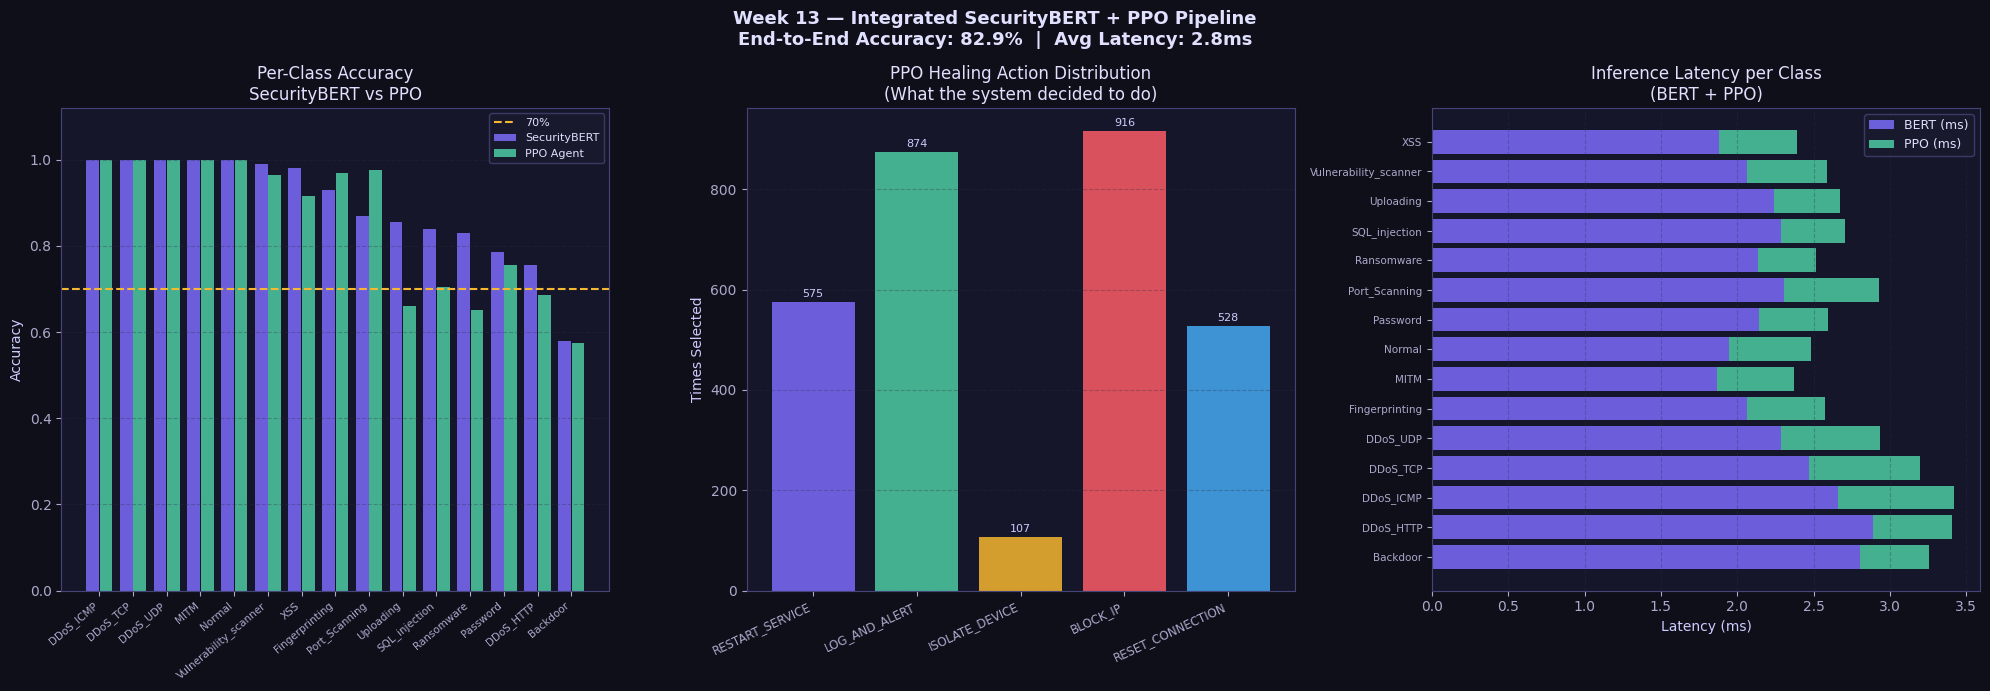

💾 Saved → ..\outputs\figures\N13/nb13_integration.png


In [8]:
# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle(
    'Week 13 — Integrated SecurityBERT + PPO Pipeline\n'
    f'End-to-End Accuracy: {overall_e2e*100:.1f}%  |  '
    f'Avg Latency: {avg_total_ms:.1f}ms',
    fontsize=13, fontweight='bold', color='#e0e0ff'
)

# BERT vs PPO per-class accuracy
ax = axes[0]
cls_sorted = sorted(CLASS_NAMES,
    key=lambda c: np.mean(bert_correct_by_cls[c]) if bert_correct_by_cls[c] else 0,
    reverse=True)
x       = np.arange(len(cls_sorted))
b_accs  = [np.mean(bert_correct_by_cls[c]) if bert_correct_by_cls[c] else 0
           for c in cls_sorted]
p_accs  = [np.mean(ppo_correct_by_cls[c])  if ppo_correct_by_cls[c]  else 0
           for c in cls_sorted]
ax.bar(x - 0.2, b_accs, 0.38, label='SecurityBERT', color=ACCENT, alpha=0.85)
ax.bar(x + 0.2, p_accs, 0.38, label='PPO Agent',    color=GREEN,  alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(cls_sorted, rotation=40, ha='right', fontsize=7.5)
ax.axhline(0.70, color=YELLOW, linewidth=1.5, linestyle='--', label='70%')
ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1.12)
ax.set_title('Per-Class Accuracy\nSecurityBERT vs PPO')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

# Action distribution
ax = axes[1]
acts   = list(action_dist.keys())
counts = [action_dist[a] for a in acts]
colors = [PALETTE[i % len(PALETTE)] for i in range(len(acts))]
bars   = ax.bar(range(len(acts)), counts,
                color=colors, edgecolor='none', alpha=0.85)
ax.set_xticks(range(len(acts)))
ax.set_xticklabels(acts, rotation=25, ha='right', fontsize=8.5)
ax.set_ylabel('Times Selected')
ax.set_title('PPO Healing Action Distribution\n(What the system decided to do)')
ax.bar_label(bars, fmt='%d', padding=2, fontsize=8, color='#ccccff')
ax.grid(axis='y', alpha=0.3)

# Latency breakdown
ax = axes[2]
lat_cls   = sorted(CLASS_NAMES)
bert_lats = [np.mean([r.bert_time_ms for r in batch_results
                      if r.true_class == c]) for c in lat_cls]
ppo_lats  = [np.mean([r.ppo_time_ms  for r in batch_results
                      if r.true_class == c]) for c in lat_cls]
x = np.arange(len(lat_cls))
ax.barh(x, bert_lats, label='BERT (ms)',    color=ACCENT, alpha=0.85)
ax.barh(x, ppo_lats,  left=bert_lats,
        label='PPO (ms)', color=GREEN,  alpha=0.85)
ax.set_yticks(x)
ax.set_yticklabels(lat_cls, fontsize=7.5)
ax.set_xlabel('Latency (ms)')
ax.set_title('Inference Latency per Class\n(BERT + PPO)')
ax.legend(fontsize=9); ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
fig.savefig(OUT_DIR / 'nb13_integration.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'💾 Saved → {OUT_DIR}/nb13_integration.png')

In [9]:
# ── Save integration checkpoint and report ────────────────────────────────────
torch.save({
    'bert_ckpt_path'    : str(BERT_CKPT),
    'ppo_ckpt_path'     : str(PPO_CKPT),
    'bert_val_accuracy' : bert_ckpt.get('val_accuracy', 0),
    'ppo_best_reward'   : ppo_ckpt.get('best_reward', 0),
    'conf_threshold'    : CONF_THRESH,
    'class_names'       : CLASS_NAMES,
    'action_names'      : ACTION_NAMES,
    'optimal_action'    : OPTIMAL_ACTION,
    'eval_results'      : {
        'overall_bert'  : float(overall_bert),
        'overall_ppo'   : float(overall_ppo),
        'overall_e2e'   : float(overall_e2e),
        'avg_bert_ms'   : float(avg_bert_ms),
        'avg_ppo_ms'    : float(avg_ppo_ms),
        'avg_total_ms'  : float(avg_total_ms),
    },
}, INTEG_CKPT)

report = {
    'week': 13,
    'pipeline': 'SecurityBERT → state_builder → PPO_Agent',
    'bert_accuracy'     : float(overall_bert),
    'ppo_accuracy'      : float(overall_ppo),
    'end_to_end_accuracy': float(overall_e2e),
    'avg_total_latency_ms': float(avg_total_ms),
    'conf_threshold'    : CONF_THRESH,
    'per_class': {
        cls: {
            'bert_acc': float(np.mean(bert_correct_by_cls[cls])) if bert_correct_by_cls[cls] else 0.0,
            'ppo_acc' : float(np.mean(ppo_correct_by_cls[cls]))  if ppo_correct_by_cls[cls]  else 0.0,
        }
        for cls in CLASS_NAMES
    },
    'action_distribution': dict(action_dist),
}
with open(INTEG_REP, 'w') as f:
    json.dump(report, f, indent=2)

print('=' * 60)
print('  ✅ Week 13 — DRL Integration Complete')
print('=' * 60)
print(f'  SecurityBERT accuracy : {overall_bert*100:.2f}%')
print(f'  PPO healing accuracy  : {overall_ppo*100:.2f}%')
print(f'  End-to-end accuracy   : {overall_e2e*100:.2f}%')
print(f'  Total latency         : {avg_total_ms:.1f} ms')
print(f'\n  📦 {INTEG_CKPT}')
print(f'  📦 {INTEG_REP}')
print(f'\n  🔜 Week 14: SelfHealingManager.execute(action)')

  ✅ Week 13 — DRL Integration Complete
  SecurityBERT accuracy : 89.43%
  PPO healing accuracy  : 85.70%
  End-to-end accuracy   : 82.93%
  Total latency         : 2.8 ms

  📦 ..\checkpoints\integrated_system.pt
  📦 ..\outputs\reports\week13_integration_report.json

  🔜 Week 14: SelfHealingManager.execute(action)
